# ANNtraining

ANN version of the training notebook for comparison with the SNN.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import sys
import os
sys.path.append(os.getcwd())
from pipeline_functions.fn_preprocess import preprocess_training
from pipeline_functions.fn_feature_extraction import extractFeatures
from pipeline_functions.ANNModule import createANN
from pipeline_functions.ANNtrain import *

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## 1. Load and preprocess all subjects

In [2]:
X = np.empty((8, 307, 99000), dtype=np.float32)
y = np.empty((99000,), dtype=np.float32)

x_idx, y_idx = 0, 0

for num_subj in range(55):
    file_name = f"C:/.mat_files/s{num_subj+1:02d}.mat"
    # print(f"Loading {file_name}")

    X_subj, y_subj, time = preprocess_training(file_name)

    epoch_num = X_subj.shape[2]
    y_len = y_subj.shape[0]

    X[:, :, x_idx:x_idx+epoch_num] = X_subj
    y[y_idx:y_idx+y_len] = y_subj

    x_idx += epoch_num
    y_idx += y_len

print("Loaded X shape:", X.shape)
print("Loaded y shape:", y.shape)

Loaded X shape: (8, 307, 99000)
Loaded y shape: (99000,)


P300 trials shape: (16500, 307)
Non-P300 trials shape: (82500, 307)


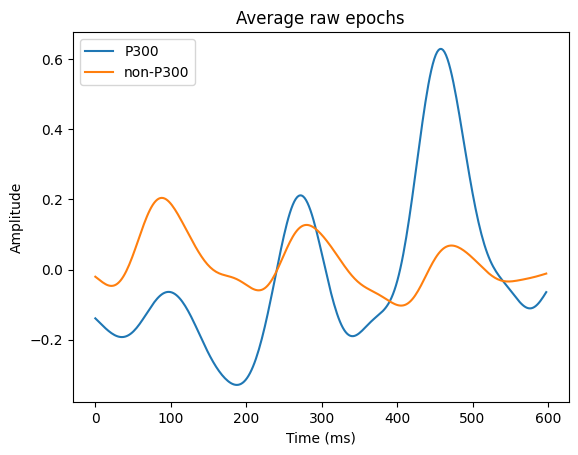

In [3]:
p300_trials = X[3, :, y == 1]
non_p300_trials = X[3, :, y == 0]

print("P300 trials shape:", p300_trials.shape)
print("Non-P300 trials shape:", non_p300_trials.shape)

avg_P300 = p300_trials.mean(axis=0)
avg_non_P300 = non_p300_trials.mean(axis=0)

time = np.arange(avg_P300.shape[0]) / 512 * 1000

plt.plot(time, avg_P300, label='P300')
plt.plot(time, avg_non_P300, label='non-P300')
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Average raw epochs")
plt.legend()
plt.show()

## 2. Feature extraction

Feature extracted shape: (99000, 8, 17)
Labels shape: (99000,)


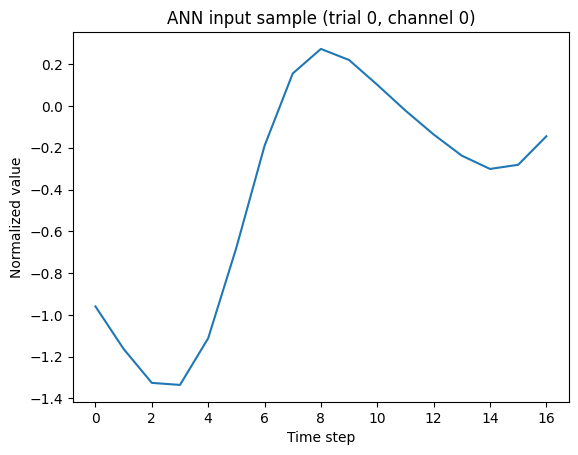

In [4]:
X_fe, y_fe = extractFeatures(X, y, t_min=200, t_max=400, norm_type='std', factor=6)

print("Feature extracted shape:", X_fe.shape)
print("Labels shape:", y_fe.shape)

plt.plot(X_fe[0, 0, :])
plt.title("ANN input sample (trial 0, channel 0)")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.show()

## 3. Prepare ANN training data

In [5]:
data = X_fe.astype(np.float32)
y_fe = y_fe.astype(np.int64)

batch_size = 256

num_features = data.shape[1] * data.shape[2]
print("Flattened ANN input size:", num_features)

train_loader, val_loader, test_loader, class_weights = prepare_training_data_ann(data, y_fe, batch_size=batch_size, balanced=False, seed=seed)

Flattened ANN input size: 136
Train size: 69300, Val size: 14850, Test size: 14850
Training Class Counts: tensor([57695, 11605])
Training Class Weights: tensor([0.3349, 1.6651])


## 4. Build ANN model

In [30]:
hidden_layer = [128, 64]
dropout = .1

torch.manual_seed(seed)

ann = createANN(dim_inputs=num_features, hidden_layer=hidden_layer, num_outputs=2, dropout=dropout)

ann.to(device)
ann

fcANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=136, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.1, inplace=False)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

## 5. Train ANN

In [36]:
num_epochs = 100
lr = 1e-3
weight_decay = 5e-4

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(ann.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

update_every = 25
checkpoint_path = None

history = train_ann(model=ann, num_epochs=num_epochs, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device, update_every=update_every, checkpoint_path=checkpoint_path)

Epoch 25: Training Loss: 0.5436, Training Accuracy: 71.70%, Training Balanced Accuracy: 72.26%,
    Validation Loss: 0.6415, Validation Accuracy: 66.34%, Validation Balanced Accuracy: 64.95%
    Predictions for each class on Training Set: tensor([44322, 24978])
    Predictions for each class on Val Set: tensor([9215, 5635])
Epoch 50: Training Loss: 0.4817, Training Accuracy: 75.41%, Training Balanced Accuracy: 76.76%,
    Validation Loss: 0.6913, Validation Accuracy: 69.97%, Validation Balanced Accuracy: 65.07%
    Predictions for each class on Training Set: tensor([45574, 23726])
    Predictions for each class on Val Set: tensor([10007,  4843])
Epoch 75: Training Loss: 0.4614, Training Accuracy: 76.84%, Training Balanced Accuracy: 78.36%,
    Validation Loss: 0.7020, Validation Accuracy: 69.93%, Validation Balanced Accuracy: 64.79%
    Predictions for each class on Training Set: tensor([46135, 23165])
    Predictions for each class on Val Set: tensor([10033,  4817])
Epoch 100: Trainin

## 6. Plot training curves

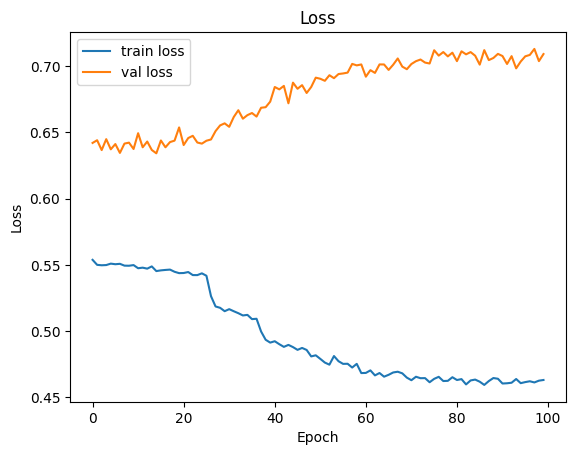

In [37]:
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

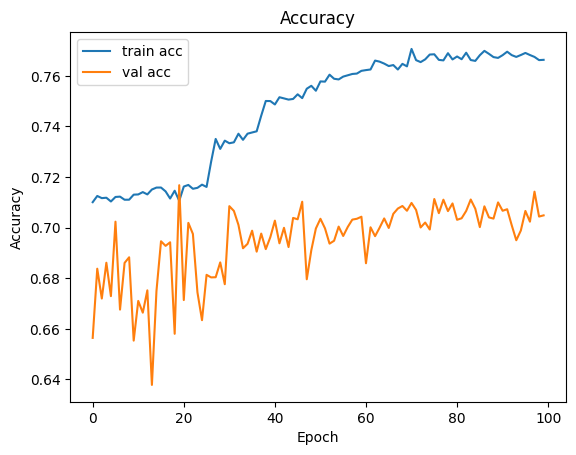

In [38]:
plt.plot(history['train_acc'], label='train acc')
plt.plot(history['val_acc'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

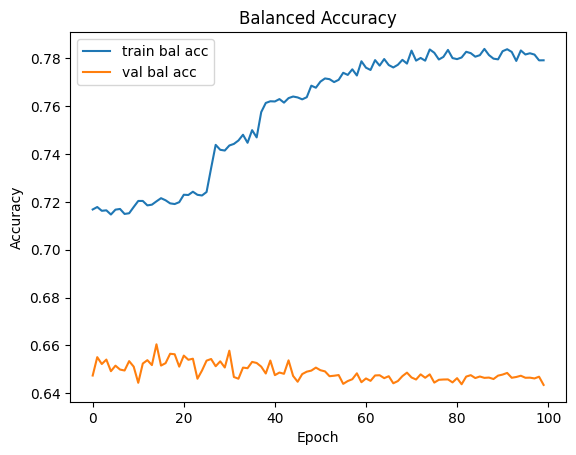

In [39]:
plt.plot(history['train_bal_acc'], label='train bal acc')
plt.plot(history['val_bal_acc'], label='val bal acc')
plt.legend()
plt.title("Balanced Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## 7. Final test-set evaluation

In [40]:
test_loss, test_acc, test_pred_counts, test_bal_acc = test_ann(ann, test_loader, criterion, device=device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Balanced Accuracy: {test_bal_acc*100:.2f}%")
print(f"Predictions for each class: {test_pred_counts}")

Test Loss: 0.7286
Test Accuracy: 69.88%
Test Balanced Accuracy: 62.82%
Predictions for each class: tensor([10263,  4587])
